In [20]:
# Load Data for Analysis
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import traceback
import json
from pathlib import Path
import traceback

import os
import sys
from pathlib import Path

# In a Jupyter Notebook, __file__ is not defined.
# Use os.getcwd() or Path.cwd() to get the current working directory,
# which is often the project root when running notebooks.
try:
    # This will work if running as a .py script
    current_file_path = Path(__file__).resolve()
    project_dir = current_file_path.parent
except NameError:
    # This will work in a Jupyter Notebook
    print("Running in Jupyter Notebook or interactive console. Using Path.cwd() for project_dir.")
    project_dir = Path.cwd() # Or Path('.').resolve()

print(f"Project directory: {project_dir}")

src_dir = project_dir / 'src'
if str(src_dir) not in sys.path:
    sys.path.append(str(src_dir))
print(f"src directory {src_dir} added to sys.path if not already there.")

from src.data_processing import load_opsin_property_data

# Set project directories
project_dir = os.path.dirname(os.path.abspath('__file__'))
output_dir = os.path.join(project_dir, 'opsin_output')
cache_dir = os.path.join(output_dir, 'cache')
grn_tables_dir = os.path.join(project_dir, 'opsin_grn_tables')

print(f"Project directory: {project_dir}")
print(f"Output directory: {output_dir}")
print(f"Cache directory: {cache_dir}")
print(f"GRN tables directory: {grn_tables_dir}")

# Initialize data dictionary
data = {}  # This will hold all our analysis data

# Function to load cached data
def load_cached_data(cache_path, description="data"):
    """Load cached data from pickle file"""
    try:
        if os.path.exists(cache_path):
            print(f"Loading {description} from cache: {cache_path}")
            with open(cache_path, 'rb') as f:
                result = pickle.load(f)
                print(f"Successfully loaded {description}")
                return result
        else:
            print(f"Cache file not found: {cache_path}")
            return None
    except Exception as e:
        print(f"Error loading {description} from cache: {e}")
        traceback.print_exc()
        return None

# Load GRN tables data if available
def load_grn_tables_data():
    grn_tables_pkl = os.path.join(grn_tables_dir, 'grn_tables_data.pkl')
    if os.path.exists(grn_tables_pkl):
        try:
            with open(grn_tables_pkl, 'rb') as f:
                grn_data = pickle.load(f)
                print(f"Successfully loaded GRN tables data")
                return grn_data
        except Exception as e:
            print(f"Error loading GRN tables data: {e}")
            traceback.print_exc()
    else:
        print(f"GRN tables data file not found: {grn_tables_pkl}")
    return None

# Load main workflow data
chain_id = 'A'

# Try to load all cached data from the workflow
cache_files = {
    "raw_structures": (f"raw_structures_{chain_id}.pkl", "raw structures"),
    "processed_structures": (f"processed_structures_{chain_id}.pkl", "processed structures"),
    "structure_errors": (f"structure_errors_{chain_id}.pkl", "structure errors"),
    "helix_annotations": (f"helix_annotations_{chain_id}.pkl", "helix annotations"),
    "structure_comparison": (f"structure_comparison_{chain_id}.pkl", "structure comparison"),
    "grn_assignment": (f"grn_assignment_{chain_id}.pkl", "GRN assignment")
}

for data_type, (file_name, description) in cache_files.items():
    cache_path = os.path.join(cache_dir, file_name)
    component_data = load_cached_data(cache_path, description)
    if component_data:
        # If the component data is a dictionary, update the main data dictionary
        if isinstance(component_data, dict):
            data.update(component_data)
        # Otherwise store it directly
        else:
            data[data_type] = component_data

# Additionally, load the GRN tables data
grn_data = load_grn_tables_data()
if grn_data:
    data.update(grn_data)
    
# Print confirmation of data loading
print(f"\nLoaded data with {len(data.keys())} top-level keys")
if 'processed_structures' in data:
    print(f"Found {len(data['processed_structures'])} processed structures")

# Load property data with correct function
property_data = load_opsin_property_data('property/mo_exp.csv', data['processed_structures'])
data['property_data'] = property_data['properties']
data['property_data'] = {
    k.replace('_smile_', '_'): v
    for k, v in data['property_data'].items()
}
data['structure_mapping'] = property_data['structure_mapping']


Running in Jupyter Notebook or interactive console. Using Path.cwd() for project_dir.
Project directory: C:\Users\hidbe\PycharmProjects\MOGRN
src directory C:\Users\hidbe\PycharmProjects\MOGRN\src added to sys.path if not already there.
Project directory: C:\Users\hidbe\PycharmProjects\MOGRN
Output directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output
Cache directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache
GRN tables directory: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_grn_tables
Cache file not found: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\raw_structures_A.pkl
Loading processed structures from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\processed_structures_A.pkl
Successfully loaded processed structures
Loading structure errors from cache: C:\Users\hidbe\PycharmProjects\MOGRN\opsin_output\cache\structure_errors_A.pkl
Successfully loaded structure errors
Loading helix annotations from cache: C:\Users\hidbe\PycharmProjects\MOGR

In [21]:
property_data.keys()

dict_keys(['properties', 'structure_mapping'])

In [22]:
data['structure_mapping']

{'3UG9': 'ChRWR_model_0',
 '1C3W': 'HsBR_model_0',
 '1UAZ': 'AR1_model_0',
 '1VGO': 'AR2_model_0',
 '6GUX': 'AR3_model_0',
 '4FBZ': 'dR3_model_0',
 '4JR8': 'cR3_model_0',
 '4PXK': 'HmBRI_D94N_model_0',
 '5KKH': 'HwBR_model_0',
 '6NWD': 'GR_model_0',
 '5AZD': 'TR_model_0',
 '3DDL': 'XR_model_0',
 '6KFQ': 'RxR_model_0',
 '4JQ6': 'Med12BPR_model_0',
 '4KLY': 'H75BPR_D97N_model_0',
 '8CQC': 'GPR_A18L_model_0',
 '4HYJ': 'ESR_model_0',
 '7AVN': 'MacR_model_0',
 '6JO0': 'VirR_model_0',
 '6LM0': 'cyR_N2098R_model_0',
 '6LM1': 'cyR_N4075R_model_0',
 '8H79': 'cyR2_P7104R_model_0',
 '7W74': 'PspR_model_0',
 '8ANQ': 'SpaR_model_0',
 '7YTB': 'Kin4B8_model_0',
 '7BMH': 'Mac_model_0',
 '6GYH': 'CsR_model_0',
 '5AWZ': 'ARI_model_0',
 '3AM6': 'ARII_model_0',
 '3A7K': 'NpHR_model_0',
 '5B2N': 'NmClR_model_0',
 '6XL3': 'MrHR_model_0',
 '7ZOU': 'SyHR_model_0',
 '8XX8': 'SsGHR_model_0',
 '3X3C': 'KR2_model_0',
 '8QLF': 'ErNaR_model_0',
 '8JH0': 'IaNaR_model_0',
 '7E4G': 'SzR4_model_0',
 '6EYU': 'NsXeR_mode

In [23]:
data['property_data'].keys()

dict_keys(['3UG9', 'CrChR1_model_0', 'FR_model_0', 'GtACR2_model_0', 'HmBRII_model_0', 'HmHR_model_0', 'HmSRI_model_0', 'HmSRII_model_0', 'HmSRIII_model_0', 'HsSRI_model_0', 'HxAR_model_0', 'KR1_model_0', 'NR_model_0', 'NdR1_model_0', 'NdR2_model_0', 'NmNaR_model_0', 'NmPR_model_0', 'PhaeoRD1_model_0', 'PhaeoRD2_model_0', 'PsChR2_model_0', 'SrSRI_model_0', 'VcChR1_model_0', 'VcChR2_model_0', 'ZipACR_model_0', 'NeoR_model_0', '1C3W', 'HsBR_model_0', '1UAZ', 'AR1_model_0', '1VGO', 'AR2_model_0', '6GUX', 'AR3_model_0', '4FBZ', 'dR3_model_0', '4JR8', 'cR3_model_0', '4PXK', 'HmBRI_D94N_model_0', '5KKH', 'HwBR_model_0', '6NWD', 'GR_model_0', '5AZD', 'TR_model_0', '3DDL', 'XR_model_0', '6KFQ', 'RxR_model_0', '4JQ6', 'Med12BPR_model_0', '4KLY', 'H75BPR_D97N_model_0', '8CQC', 'GPR_A18L_model_0', '4HYJ', 'ESR_model_0', '7AVN', 'MacR_model_0', '6JO0', 'VirR_model_0', '6LM0', 'cyR_N2098R_model_0', '6LM1', 'cyR_N4075R_model_0', '8H79', 'cyR2_P7104R_model_0', '7W74', 'PspR_model_0', '8ANQ', 'SpaR_mo

In [24]:
# Import visualization functions
from src.visualization_functions import (
    create_opsin_overview_plot, create_rmsd_color_scale_figure,
    create_and_visualize_similarity_tree, visualize_rmsd_matrix_improved,
    plot_similarity_tree, plot_rmsd_heatmap,
    plot_distances_with_std, plot_average_distances_by_helix, plot_distance_heatmap,
    create_residue_conservation_plot, plot_helix_logo_plots, plot_conservation_around_x50,
    create_combined_distance_logo_plot, visualize_binding_pocket
)

# Import the color scheme tools
from src.opsin_color_scheme import get_group_colors, RMSD_COMPACT_CMAP

In [25]:
# Assuming this function is in your visualizations.py or a similar file
# And that opsin_color_scheme.py is in src.opsin_color_scheme

import matplotlib.pyplot as plt # Ensure Patch is imported if not already
from matplotlib.patches import Patch
from matplotlib.lines import Line2D # For better legend dots
import numpy as np
import pandas as pd

# Import from our updated color scheme
from src.opsin_color_scheme import (
    OPSIN_COLORS, # For fallback colors, dot colors, etc.
    get_group_colors # Crucial for dynamic color assignment
)


def create_opsin_overview_plot(df, output_path=None, figsize=(16, 16)):
    """
    Create a circular overview plot of opsin structures with multiple rings showing
    molecular function, domain, and experimental/predicted status.
    Uses the consistent color scheme with updated property palettes.

    Args:
        df: DataFrame with opsin information, must include columns:
            - molecular_function_normalized: Function category
            - domain: Taxonomic domain
            - experimentally_determined: Boolean flag for experimental structures
            - short_name: Short identifier for each structure
        output_path: Path to save the figure (optional)
        figsize: Figure size tuple (width, height)

    Returns:
        Matplotlib figure with circular plot
    """
    df_copy = df.copy()
    df_copy['molecular_function_normalized'] = df_copy['molecular_function_normalized'].fillna('Unknown')
    df_copy['domain'] = df_copy['domain'].fillna('Unknown')
    df_sorted = df_copy.sort_values(by=['molecular_function_normalized', 'domain', 'short_name'], ignore_index=True)

    N = len(df_sorted)

    if N == 0:
        fig, ax = plt.subplots(figsize=figsize)
        ax.text(0.5, 0.5, "No data to plot.", ha='center', va='center', transform=ax.transAxes)
        if output_path:
            fig.savefig(output_path, dpi=300, bbox_inches='tight')
        return fig

    # --- Color Assignment using the new scheme ---
    # Ring 1: Molecular Function (Yellow -> Red -> Purple palette)
    unique_functions = df_sorted['molecular_function_normalized'].unique()
    # 'palette_type="default"' or 'palette_type="mol_func"' will now use the
    # MOL_FUNC_PROPERTY_COLORS (Yellow -> Purple) for unassigned groups.
    function_colors_dict = get_group_colors(unique_functions, palette_type='default')

    # Ring 2: Domain (Blue -> Cyan -> Green palette)
    unique_domains = df_sorted['domain'].unique()
    # 'palette_type="domain"' will now use the
    # DOMAIN_PROPERTY_COLORS (Blue -> Green) for unassigned groups.
    domain_colors_dict = get_group_colors(unique_domains, palette_type='domain')

    ring1_colors = [function_colors_dict.get(f, OPSIN_COLORS['gray_3'])
                    for f in df_sorted['molecular_function_normalized']]
    ring2_colors = [domain_colors_dict.get(d, OPSIN_COLORS['gray_3'])
                    for d in df_sorted['domain']]

    # Ring 3 & 4: Status dots
    if 'experimentally_determined' in df_sorted.columns and df_sorted['experimentally_determined'].dtype != bool:
        df_sorted['experimentally_determined'] = df_sorted['experimentally_determined'].astype(str).str.lower().map({'true': True, '1': True, 'yes': True}).fillna(False)
    elif 'experimentally_determined' not in df_sorted.columns:
        df_sorted['experimentally_determined'] = False # Assume not experimental if column missing

    ring3_labels = ['•' if x else '' for x in df_sorted['experimentally_determined']]
    # Assuming 'is_predicted' column exists, otherwise adjust logic for Ring 4
    if 'is_predicted' in df_sorted.columns and df_sorted['is_predicted'].dtype != bool:
         df_sorted['is_predicted'] = df_sorted['is_predicted'].astype(str).str.lower().map({'true': True, '1': True, 'yes': True}).fillna(False)
    elif 'is_predicted' not in df_sorted.columns:
        # If 'is_predicted' column doesn't exist, assume predicted if not experimental
        df_sorted['is_predicted'] =True


    ring4_labels = ['•' if x else '' for x in df_sorted['is_predicted']]


    fig = plt.figure(figsize=figsize)
    ax = fig.add_axes([0.05, 0.05, 0.7, 0.9])

    R1_RADIUS, R2_RADIUS, R3_RADIUS, R4_RADIUS = 0.65, 0.85, 0.93, 0.98
    SLICE_WIDTH = 0.18
    DOT_RING_WIDTH = 0.03

    ax.pie([1] * N, colors=ring1_colors, radius=R1_RADIUS,
           wedgeprops=dict(width=SLICE_WIDTH, edgecolor=OPSIN_COLORS['white']),
           startangle=90, counterclock=False)
    ax.pie([1] * N, colors=ring2_colors, radius=R2_RADIUS,
           wedgeprops=dict(width=SLICE_WIDTH, edgecolor=OPSIN_COLORS['white']),
           startangle=90, counterclock=False)

    _, texts3 = ax.pie([1] * N, labels=ring3_labels, radius=R3_RADIUS, labeldistance=1.02,
                       wedgeprops=dict(width=DOT_RING_WIDTH, edgecolor=OPSIN_COLORS['white'], facecolor='none'),
                       startangle=90, counterclock=False,
                       textprops={'va':'center', 'ha':'center', 'fontsize': 16, 'color': OPSIN_COLORS['black']})

    _, texts4 = ax.pie([1] * N, labels=ring4_labels, radius=R4_RADIUS, labeldistance=1.02,
                       wedgeprops=dict(width=DOT_RING_WIDTH, edgecolor=OPSIN_COLORS['white'], facecolor='none'),
                       startangle=90, counterclock=False,
                       textprops={'va':'center', 'ha':'center', 'fontsize': 16, 'color': OPSIN_COLORS['green']}) # Using the 'green' alias from OPSIN_COLORS

    ax.set_title("Opsin Structures Overview", pad=30, fontsize=18, fontweight='bold')

    # --- Create Legends ---
    legend_elements_func = [Patch(facecolor=color, label=func)
                            for func, color in sorted(function_colors_dict.items())
                            if func in unique_functions and func != "Unknown"]
    if "Unknown" in function_colors_dict and "Unknown" in unique_functions:
        legend_elements_func.append(Patch(facecolor=function_colors_dict["Unknown"], label="Unknown Function"))

    legend_elements_domain = [Patch(facecolor=color, label=domain_val)
                              for domain_val, color in sorted(domain_colors_dict.items())
                              if domain_val in unique_domains and domain_val != "Unknown"]
    if "Unknown" in domain_colors_dict and "Unknown" in unique_domains:
        legend_elements_domain.append(Patch(facecolor=domain_colors_dict["Unknown"], label="Unknown Domain"))

    legend_elements_status = [
        Line2D([0], [0], marker='o', color='w', label='Experimental', markersize=8, markerfacecolor=OPSIN_COLORS['black']),
        Line2D([0], [0], marker='o', color='w', label='Predicted', markersize=8, markerfacecolor=OPSIN_COLORS['green'])
    ]

    leg_ax = fig.add_axes([0.72, 0.15, 0.25, 0.7])
    leg_ax.axis('off')
    all_legends = []

    if legend_elements_func:
        leg1 = leg_ax.legend(handles=legend_elements_func, title="Molecular Function",
                             loc="upper left", fontsize=10, title_fontsize=12, frameon=False)
        all_legends.append(leg1)

    current_y_offset = 0.80
    if legend_elements_domain:
        # Attempt to calculate offset based on number of items for better spacing
        # This is approximate and might need tuning
        num_domain_items = len(legend_elements_domain)
        domain_legend_height_approx = (num_domain_items * 0.035) + 0.05 # Title + items
        current_y_offset = 1.0 - ((len(legend_elements_func) * 0.035) + 0.05 + 0.05) # Start below first legend


        leg2 = leg_ax.legend(handles=legend_elements_domain, title="Domain",
                             loc="upper left", bbox_to_anchor=(0, current_y_offset),
                             fontsize=10, title_fontsize=12, frameon=False)
        all_legends.append(leg2)
        current_y_offset -= (domain_legend_height_approx + 0.05) # Space for next legend

    if legend_elements_status:
        leg3 = leg_ax.legend(handles=legend_elements_status, title="Status",
                             loc="upper left", bbox_to_anchor=(0, current_y_offset),
                             fontsize=10, title_fontsize=12, frameon=False)
        all_legends.append(leg3)

    for leg_item in all_legends[:-1]:
        if leg_item: # Ensure legend was created
            leg_ax.add_artist(leg_item)

    if output_path:
        fig.savefig(output_path, dpi=300, bbox_inches='tight')

    return fig

A1ACR1_J318_refine3
TsChR_J132_refine3
A1ACR1_J318_refine3_model_0
R2ACR_J315_refine8_model_0
R2ACR_J315_refine8
KnChR_J444_refine5_model_0
ChroME2s_J227_refine3_model_0
bReaChES_J215_refine6_model_0
CoChR_J248_refine7
ChroME2s_J227_refine3
bReaChES_J215_refine6
CnChR2_J230_refine9_model_0
CoChR_J248_refine7_model_0
KnChR_J444_refine5
CnChR2_J230_refine9
TsChR_J132_refine3_model_0


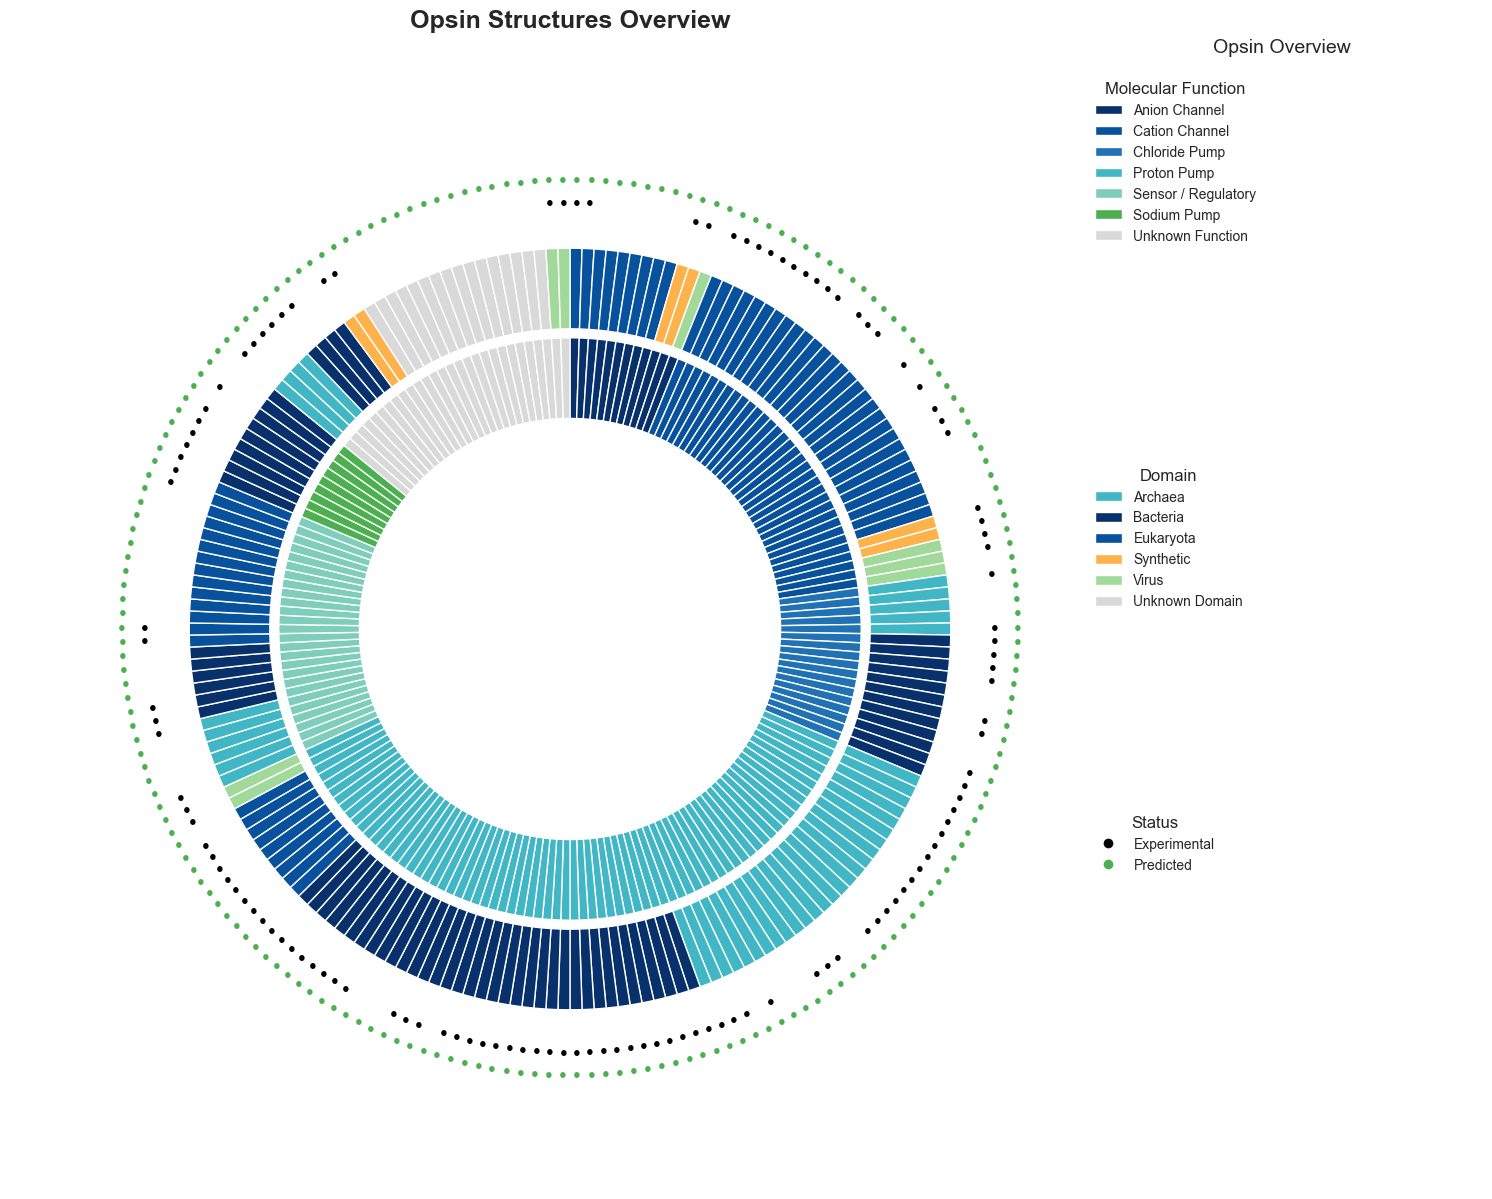

In [26]:
# Visualization 1: Opsins Overview Plot

# First, prepare overview data
overview_data_list = []
processed_structures_map = data.get('processed_structures', {})
property_data_map = data.get('property_data', {})

for sid, struct_info in processed_structures_map.items():
    if sid in property_data_map.keys():
        # print(sid)
        pass
    else:
        print(sid)
    mf, domain, is_experimental, display_name = "Unknown", "Unknown", False, sid
    
    # Try to get properties from property_data_map
    prop_entry = property_data_map.get(sid)
    
    if prop_entry and isinstance(prop_entry, dict):
        mf_val = prop_entry.get('molecular_function')
        if pd.notna(mf_val) and str(mf_val).strip() and str(mf_val).lower() != "unknown": 
            mf = str(mf_val)
            
        domain_val = prop_entry.get('domain')
        if pd.notna(domain_val) and str(domain_val).strip() and str(domain_val).lower() != "unknown": 
            domain = str(domain_val)
            
        is_experimental_prop = prop_entry.get('experimentally_determined', False)
        if isinstance(is_experimental_prop, str):
            is_experimental = is_experimental_prop.lower() == 'true'
        elif isinstance(is_experimental_prop, bool):
            is_experimental = is_experimental_prop
            
        display_name_prop = prop_entry.get('short_name', prop_entry.get('display_name'))
        if pd.notna(display_name_prop) and str(display_name_prop).strip(): 
            display_name = str(display_name_prop)
    
    # Fallback to structure info if needed
    if isinstance(struct_info, dict):
        struct_props = struct_info.get('properties', {})
        if isinstance(struct_props, dict):
            if mf == "Unknown":
                mf_val_struct = struct_props.get('molecular_function')
                if pd.notna(mf_val_struct) and str(mf_val_struct).strip() and str(mf_val_struct).lower() != "unknown": 
                    mf = str(mf_val_struct)
                    
            if domain == "Unknown":
                domain_val_struct = struct_props.get('domain')
                if pd.notna(domain_val_struct) and str(domain_val_struct).strip() and str(domain_val_struct).lower() != "unknown": 
                    domain = str(domain_val_struct)
    
    overview_data_list.append({
        'id': sid,
        'short_name': display_name, 
        'molecular_function_normalized': mf,
        'domain': domain, 
        'experimentally_determined': is_experimental
    })

overview_df = pd.DataFrame(overview_data_list)
flat_list = []
for k, v in data['structure_mapping'].items():
    flat_list.append(k)
    flat_list.append(v)




overview_df['experimentally_determined'] = overview_df['id'].isin(flat_list)


# Create overview plot
fig_overview = create_opsin_overview_plot(overview_df)
plt.title("Opsin Overview")
plt.show()

In [27]:
data['structure_mapping']

{'3UG9': 'ChRWR_model_0',
 '1C3W': 'HsBR_model_0',
 '1UAZ': 'AR1_model_0',
 '1VGO': 'AR2_model_0',
 '6GUX': 'AR3_model_0',
 '4FBZ': 'dR3_model_0',
 '4JR8': 'cR3_model_0',
 '4PXK': 'HmBRI_D94N_model_0',
 '5KKH': 'HwBR_model_0',
 '6NWD': 'GR_model_0',
 '5AZD': 'TR_model_0',
 '3DDL': 'XR_model_0',
 '6KFQ': 'RxR_model_0',
 '4JQ6': 'Med12BPR_model_0',
 '4KLY': 'H75BPR_D97N_model_0',
 '8CQC': 'GPR_A18L_model_0',
 '4HYJ': 'ESR_model_0',
 '7AVN': 'MacR_model_0',
 '6JO0': 'VirR_model_0',
 '6LM0': 'cyR_N2098R_model_0',
 '6LM1': 'cyR_N4075R_model_0',
 '8H79': 'cyR2_P7104R_model_0',
 '7W74': 'PspR_model_0',
 '8ANQ': 'SpaR_model_0',
 '7YTB': 'Kin4B8_model_0',
 '7BMH': 'Mac_model_0',
 '6GYH': 'CsR_model_0',
 '5AWZ': 'ARI_model_0',
 '3AM6': 'ARII_model_0',
 '3A7K': 'NpHR_model_0',
 '5B2N': 'NmClR_model_0',
 '6XL3': 'MrHR_model_0',
 '7ZOU': 'SyHR_model_0',
 '8XX8': 'SsGHR_model_0',
 '3X3C': 'KR2_model_0',
 '8QLF': 'ErNaR_model_0',
 '8JH0': 'IaNaR_model_0',
 '7E4G': 'SzR4_model_0',
 '6EYU': 'NsXeR_mode

In [28]:
overview_df

,id,short_name,molecular_function_normalized,domain,experimentally_determined
0,5B2N,5B2N,Chloride Pump,Bacteria,True
1,A1ACR1_J318_refine3,A1ACR1_J318_refine3,Unknown,Unknown,False
2,HsHR_model_0,HsHR_model_0,Chloride Pump,Archaea,False
3,NeoR_model_0,NeoR_model_0,Sensor / Regulatory,Eukaryota,False
4,7ZMY,7ZMY,Proton Pump,Bacteria,True
...,...,...,...,...,...
193,3X3C,3X3C,Sodium Pump,Bacteria,True
194,ZipACR__model_0,ZipACR__model_0,Anion Channel,Eukaryota,False
195,8YEL,8YEL,Cation Channel,Eukaryota,True
196,TsChR_J132_refine3_model_0,TsChR_J132_refine3_model_0,Unknown,Unknown,False


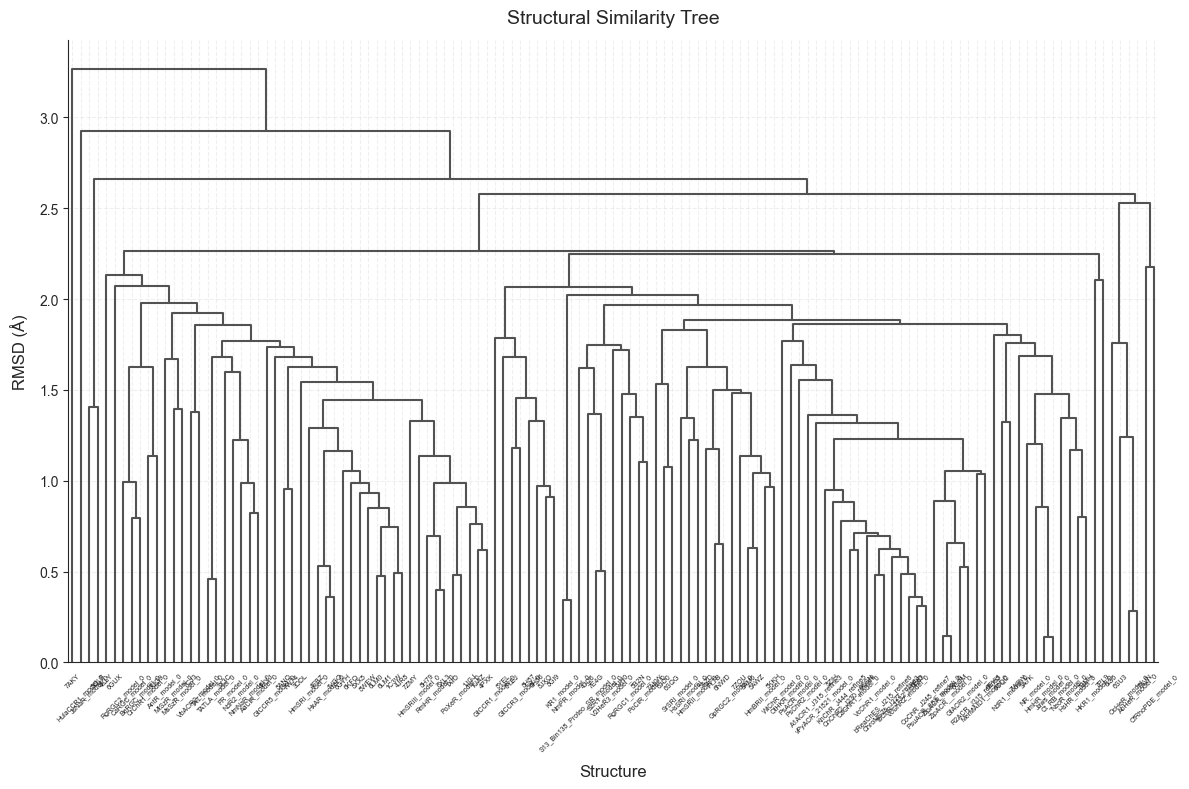

In [29]:
# Visualization 2: Structural Similarity Tree

# Create a group dictionary mapping structure IDs to molecular functions
group_dict = {}
domain_dict = {}

for item in overview_data_list:
    group_dict[item['id']] = item['molecular_function_normalized']
    domain_dict[item['id']] = {'domain': item['domain'], 'average_error': None}

# Get RMSD matrix from data
if 'rmsd_matrix' in data and isinstance(data['rmsd_matrix'], pd.DataFrame):
    rmsd_df = data['rmsd_matrix']
elif 'rmsd_df' in data and isinstance(data['rmsd_df'], pd.DataFrame):
    rmsd_df = data['rmsd_df']
else:
    print("RMSD matrix not found in data")
    rmsd_df = pd.DataFrame()

if not rmsd_df.empty:
    # Create similarity tree
    fig_tree = plot_similarity_tree(rmsd_df, title="Structural Similarity Tree")
    plt.show()

In [31]:
# Visualization 3: RMSD Heatmap

if not rmsd_df.empty:
  fig_heatmap = visualize_rmsd_matrix_improved(
      rmsd_df=rmsd_df,
      group_dict=group_dict,      # Molecular function (warm colors)
      domain_dict=domain_dict,    # Domain info (cold colors)
      figsize=(14, 12)
  )
  plt.show()


ERROR (Heatmap): Linkage matrix (Z) is required for visualize_rmsd_matrix_improved.


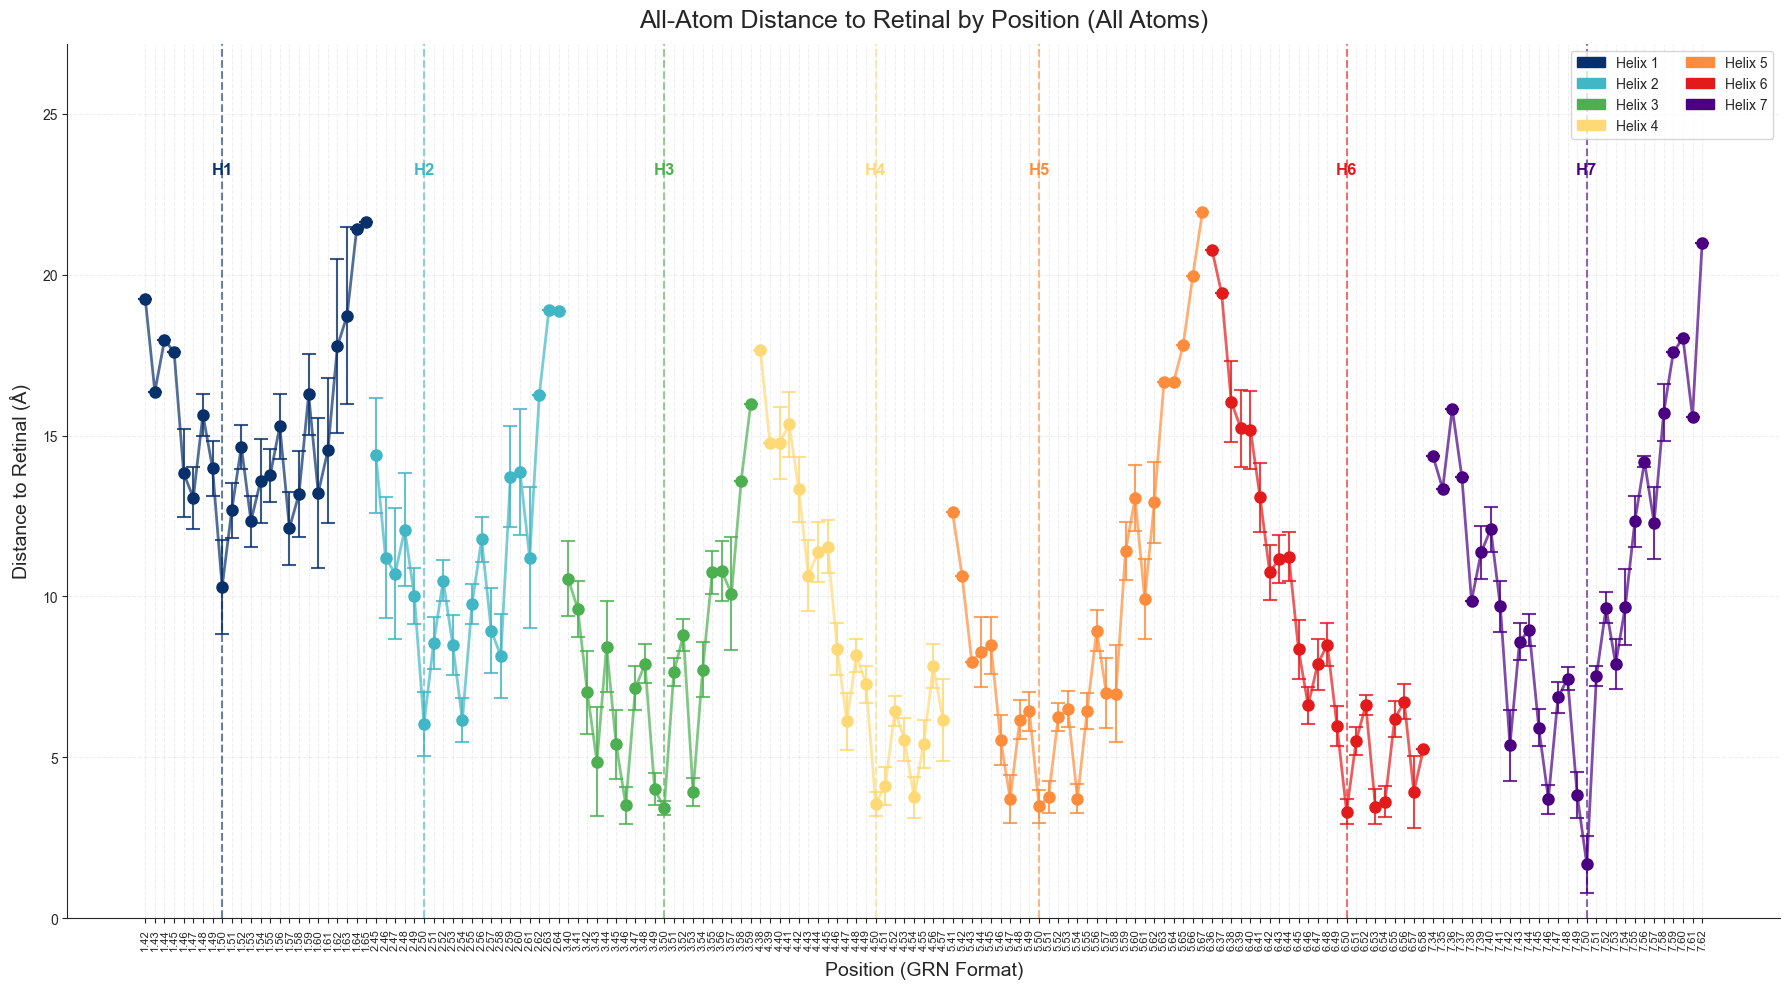

In [12]:
# Visualization 4: Distance to Retinal Plot

# Check if distance tables are available
distance_table = None
if 'distance_table' in data and isinstance(data['distance_table'], pd.DataFrame):
    distance_table = data['distance_table']

if distance_table is not None and not distance_table.empty:
    # Create distance plot
    fig_distance = plot_distances_with_std(distance_table, 
                                          title="All-Atom Distance to Retinal by Position", 
                                          use_ca=False)
    plt.show()

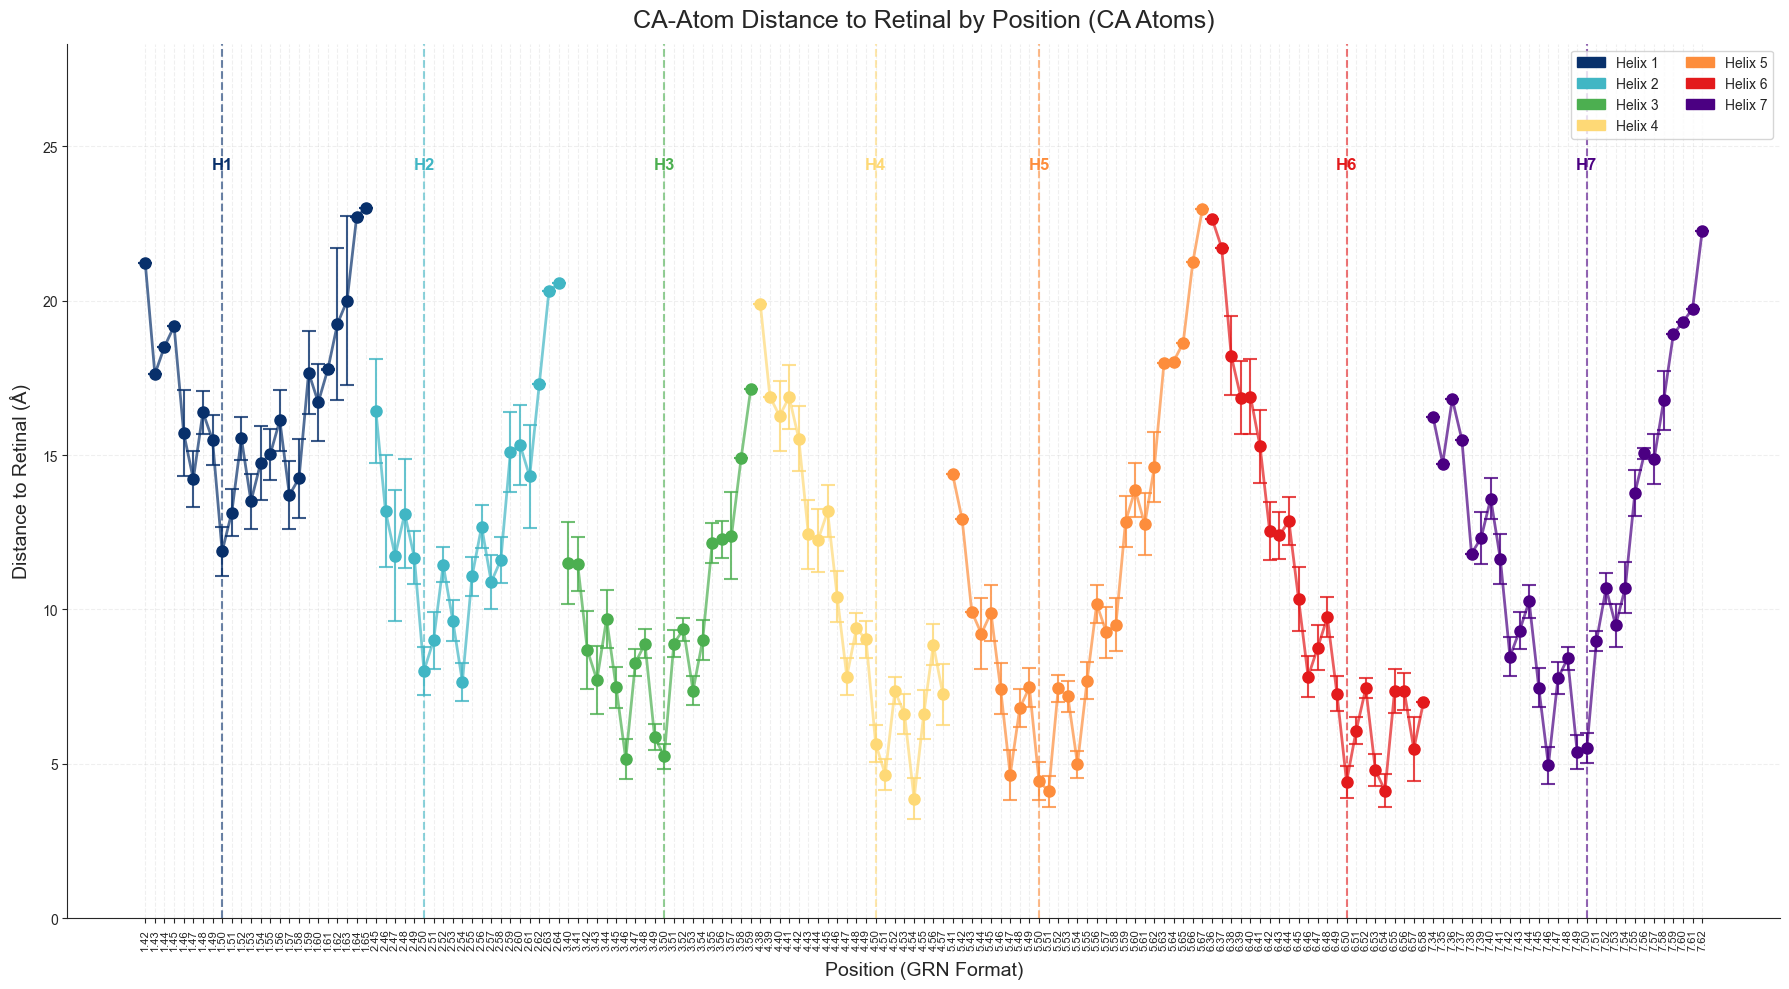

In [13]:
# Visualization 5: CA-Atom Distance to Retinal Plot

# Check if CA distance table is available
ca_distance_table = None
if 'ca_distance_table' in data and isinstance(data['ca_distance_table'], pd.DataFrame):
    ca_distance_table = data['ca_distance_table']

if ca_distance_table is not None and not ca_distance_table.empty:
    # Create CA distance plot
    fig_ca_distance = plot_distances_with_std(ca_distance_table, 
                                             title="CA-Atom Distance to Retinal by Position", 
                                             use_ca=True)
    plt.show()

In [14]:
data.keys()

dict_keys(['processed_structures', 'structure_mapping', 'hide_errors_df', 'mo_exp_errors_df', 'binding_pocket_results', 'binding_results_mo_exp', 'reference_structure', 'helix_definitions', 'alignment_paths', 'helix_annotations_file', 'rmsd_df', 'rmsd_matrix', 'pdb_list', 'group_dict', 'name_dict', 'seq_alignment_dicts', 'msa_df', 'distance_table', 'ca_msa_df', 'ca_distance_table', 'global_ref', 'type_reference_dict', 'tree_seq_alignment_dicts', 'tree_msa_df', 'tree_distance_table', 'tree_ca_msa_df', 'tree_ca_distance_table', 'tree_central_ref', 'tree_enhanced_paths', 'property_data'])

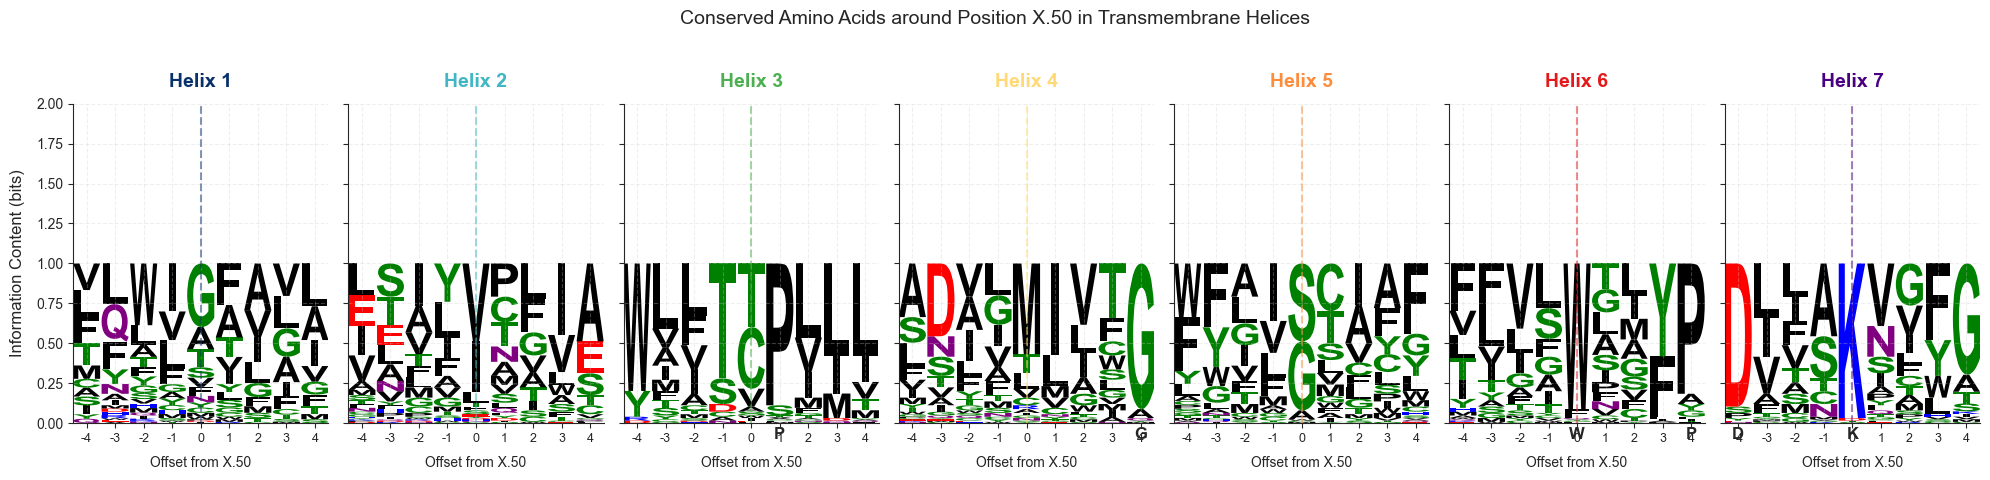

In [15]:
# Visualization 7: Helix Logo Plots

# Check if residue table or MSA is available for logo plots
residue_table_for_logo = None
if 'msa_df' in data and isinstance(data['msa_df'], pd.DataFrame):
    residue_table_for_logo = data['msa_df']
elif msa_table is not None:
    residue_table_for_logo = msa_table

if residue_table_for_logo is not None and not residue_table_for_logo.empty:
    # Create logo plots
    fig_logo = plot_helix_logo_plots(residue_table_for_logo)
    plt.show()

In [16]:
distance_table['7.50']

MerMAID1_model_0                1.560349
5B2N                            1.274920
A1ACR1_J318_refine3             1.264279
HsHR_model_0                    1.820713
NeoR_model_0                    1.316280
                                  ...   
6LM1                            1.263479
3X3C                            1.471878
ZipACR__model_0                 1.321116
8YEL                            1.343610
S13_Bin138_Proteo_SR_model_0    1.540153
Name: 7.50, Length: 125, dtype: float64

In [35]:
residue_table_for_logo

,n.3,n.2,n.1,1.42,1.43,1.44,1.45,1.46,1.47,1.48,...,c.27,c.28,c.29,c.30,c.31,c.32,c.33,c.34,c.35,c.36
MerMAID1_model_0,M1,V2,P3,I4,Y5,A6,T7,F8,Q9,L10,...,N253,Y254,P255,L256,D257,K258,I259,I260,Q261,T262
5B2N,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
A1ACR1_J318_refine3,-,-,-,-,-,-,-,A103,R104,L105,...,-,-,-,-,-,-,-,-,-,-
HsHR_model_0,-,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
NeoR_model_0,-,-,-,-,-,-,-,-,Y66,K67,...,-,-,-,-,-,-,-,-,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6LM1,-,-,-,-,-,-,-,-,L9,W10,...,-,-,-,-,-,-,-,-,-,-
3X3C,-,-,-,-,-,-,-,-,L32,T33,...,-,-,-,-,-,-,-,-,-,-
ZipACR__model_0,-,-,-,-,-,-,-,F52,Q53,L54,...,-,-,-,-,-,-,-,-,-,-
8YEL,-,-,-,-,-,-,-,-,D39,W40,...,-,-,-,-,-,-,-,-,-,-


In [36]:
distance_table.columns.tolist()

['n.3',
 'n.2',
 'n.1',
 '1.42',
 '1.43',
 '1.44',
 '1.45',
 '1.46',
 '1.47',
 '1.48',
 '1.49',
 '1.50',
 '1.51',
 '1.52',
 '1.53',
 '1.54',
 '1.55',
 '1.56',
 '1.57',
 '1.58',
 '1.59',
 '1.60',
 '1.61',
 '1.62',
 '1.63',
 '1.64',
 '1.65',
 '2.45',
 '2.46',
 '2.47',
 '2.48',
 '2.49',
 '2.50',
 '2.51',
 '2.52',
 '2.53',
 '2.54',
 '2.55',
 '2.56',
 '2.57',
 '2.58',
 '2.59',
 '2.60',
 '2.61',
 '2.62',
 '2.63',
 '2.64',
 '3.40',
 '3.41',
 '3.42',
 '3.43',
 '3.44',
 '3.45',
 '3.46',
 '3.47',
 '3.48',
 '3.49',
 '3.50',
 '3.51',
 '3.52',
 '3.53',
 '3.54',
 '3.55',
 '3.56',
 '3.57',
 '3.58',
 '3.59',
 '4.38',
 '4.39',
 '4.40',
 '4.41',
 '4.42',
 '4.43',
 '4.44',
 '4.45',
 '4.46',
 '4.47',
 '4.48',
 '4.49',
 '4.50',
 '4.51',
 '4.52',
 '4.53',
 '4.54',
 '4.55',
 '4.56',
 '4.57',
 '5.41',
 '5.42',
 '5.43',
 '5.44',
 '5.45',
 '5.46',
 '5.47',
 '5.48',
 '5.49',
 '5.50',
 '5.51',
 '5.52',
 '5.53',
 '5.54',
 '5.55',
 '5.56',
 '5.57',
 '5.58',
 '5.59',
 '5.60',
 '5.61',
 '5.62',
 '5.63',
 '5.64',
 '5.

In [51]:
residue_table_for_logo.columns.tolist()

['n.3',
 'n.2',
 'n.1',
 '1.42',
 '1.43',
 '1.44',
 '1.45',
 '1.46',
 '1.47',
 '1.48',
 '1.49',
 '1.50',
 '1.51',
 '1.52',
 '1.53',
 '1.54',
 '1.55',
 '1.56',
 '1.57',
 '1.58',
 '1.59',
 '1.60',
 '1.61',
 '1.62',
 '1.63',
 '1.64',
 '1.65',
 '2.45',
 '2.46',
 '2.47',
 '2.48',
 '2.49',
 '2.50',
 '2.51',
 '2.52',
 '2.53',
 '2.54',
 '2.55',
 '2.56',
 '2.57',
 '2.58',
 '2.59',
 '2.60',
 '2.61',
 '2.62',
 '2.63',
 '2.64',
 '3.40',
 '3.41',
 '3.42',
 '3.43',
 '3.44',
 '3.45',
 '3.46',
 '3.47',
 '3.48',
 '3.49',
 '3.50',
 '3.51',
 '3.52',
 '3.53',
 '3.54',
 '3.55',
 '3.56',
 '3.57',
 '3.58',
 '3.59',
 '4.38',
 '4.39',
 '4.40',
 '4.41',
 '4.42',
 '4.43',
 '4.44',
 '4.45',
 '4.46',
 '4.47',
 '4.48',
 '4.49',
 '4.50',
 '4.51',
 '4.52',
 '4.53',
 '4.54',
 '4.55',
 '4.56',
 '4.57',
 '5.41',
 '5.42',
 '5.43',
 '5.44',
 '5.45',
 '5.46',
 '5.47',
 '5.48',
 '5.49',
 '5.50',
 '5.51',
 '5.52',
 '5.53',
 '5.54',
 '5.55',
 '5.56',
 '5.57',
 '5.58',
 '5.59',
 '5.60',
 '5.61',
 '5.62',
 '5.63',
 '5.64',
 '5.

In [58]:
from protos.processing.grn.grn_utils import sort_grns_str

In [62]:
def create_combined_distance_logo_plot(distance_table, msa_df):
    """
    Create a combined figure with a distance line plot on top and a sequence logo below,
    with precisely aligned x-axes for both dot notation (1.50) and x notation (1x50) GRN formats.

    Args:
        distance_table: DataFrame with distances for plotting (columns as GRN positions)
        msa_df: Multiple sequence alignment DataFrame (columns as GRN positions)
    Returns:
        Matplotlib figure
    """

    if distance_table.empty or msa_df.empty:
        fig, ax = plt.subplots(figsize=(15,10))
        ax.text(0.5,0.5, "Distance or MSA data is empty. Cannot create combined plot.",
                ha='center', va='center', transform=ax.transAxes)
        return fig

    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 0.6], hspace=0.05)
    ax_top = fig.add_subplot(gs[0])
    ax_bottom = fig.add_subplot(gs[1], sharex=ax_top) # Share x-axis

    mean_distances = distance_table.mean(skipna=True)
    
    # Get common GRNs present in both distance and MSA, then sort them
    common_grn_index = mean_distances.index.intersection(msa_df.columns)
    if common_grn_index.empty:
        ax_top.text(0.5,0.5, "No common GRNs between distance and MSA data.", ha='center', va='center')
        ax_bottom.text(0.5,0.5, "", ha='center', va='center') # Clear bottom too
        return fig
    
    try: # Attempt GRN Utils sorting if available
        sorted_common_grns = sort_grns_str(common_grn_index.astype(str).tolist())
    except ImportError:
        sorted_common_grns = sorted(common_grn_index.astype(str), key=grn_sort_key)
    print(sorted_common_grns)
    
    x_values = np.arange(len(sorted_common_grns))
    y_values_dist = [mean_distances[grn] for grn in sorted_common_grns]
    
    ax_top.plot(x_values, y_values_dist, 'o-', color='blue', linewidth=2)
    ax_top.set_title('Distance to Retinal and Sequence Conservation', fontsize=14)
    ax_top.set_ylabel('Average Distance to Retinal (Å)', fontsize=12)
    ax_top.grid(True, alpha=0.3)

    max_y_dist = (max(y_values_dist) if y_values_dist else 10)
    for i, grn in enumerate(sorted_common_grns):
        grn_str = str(grn)
        # Check for .50 in dot notation or x50 in x notation
        is_x50 = (grn_str.endswith('.50') and grn_str.split('.')[0].isdigit()) or \
                   ('x50' in grn_str and grn_str.split('x')[0].isdigit())
        if is_x50:
            ax_top.axvline(x=i, color='gray', linestyle='--', alpha=0.7)
            ax_top.text(i, max_y_dist * 0.95, grn_str,
                        rotation=90, ha='center', va='top', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False) # Hide x-ticks on top plot


    # --- Sequence Logo Plot (Bottom) ---
    filtered_msa_for_logo = msa_df[sorted_common_grns] # Use sorted common GRNs for columns

    # PWM calculation
    amino_acids = list('ACDEFGHIKLMNPQRSTVWY')
    # Initialize pwm_df with correct columns (amino_acids) and index matching x_values
    pwm_df = pd.DataFrame(0.0, index=x_values, columns=amino_acids)

    for i, grn_col in enumerate(sorted_common_grns): # Iterate using index i and GRN column name
        aa_counts = Counter()
        valid_aas_at_pos = 0
        for seq_val in filtered_msa_for_logo[grn_col]:
            if isinstance(seq_val, str) and len(seq_val) > 0 and seq_val[0] != '-':
                aa = seq_val[0].upper()
                if aa in amino_acids:
                    aa_counts[aa] += 1
                    valid_aas_at_pos +=1
        print(aa_counts)

        if valid_aas_at_pos > 0:
            for aa, count in aa_counts.items():
                pwm_df.loc[i, aa] = count / valid_aas_at_pos # Use index i for pwm_df.loc

    if not pwm_df.empty and pwm_df.sum().sum() > 0:
        aa_colors_logo = { # Renamed aa_colors to avoid conflict
            'A': OPSIN_COLORS['blue_light'], 'C': OPSIN_COLORS['yellow'],
            'D': OPSIN_COLORS['red'], 'E': OPSIN_COLORS['red'],
            'F': OPSIN_COLORS['blue_dark'], 'G': OPSIN_COLORS['orange'],
            'H': OPSIN_COLORS['teal'], 'I': OPSIN_COLORS['blue_light'],
            'K': OPSIN_COLORS['blue_dark'], 'L': OPSIN_COLORS['blue_light'],
            'M': OPSIN_COLORS['blue_light'], 'N': OPSIN_COLORS['green'],
            'P': OPSIN_COLORS['yellow'], 'Q': OPSIN_COLORS['green'],
            'R': OPSIN_COLORS['blue_dark'], 'S': OPSIN_COLORS['green'],
            'T': OPSIN_COLORS['green'], 'V': OPSIN_COLORS['blue_light'],
            'W': OPSIN_COLORS['blue_dark'], 'Y': OPSIN_COLORS['blue_dark'],
            '-': OPSIN_COLORS['gray_light'] # Though '-' is excluded from PWM
        }
        try:
            lm_logo = logomaker.Logo(pwm_df, ax=ax_bottom, color_scheme=aa_colors_logo)
            lm_logo.style_spines(visible=False)
            # X-ticks are shared, labels set on bottom plot
            ax_bottom.set_xticks(x_values)
            ax_bottom.set_xticklabels(sorted_common_grns, rotation=90, fontsize=8)
        except Exception as e_logo:
            print(f"Error creating sequence logo for combined plot: {e_logo}")
            ax_bottom.text(0.5,0.5, "Logo generation error", ha='center', va='center')
            ax_bottom.set_xticks(x_values)
            ax_bottom.set_xticklabels(sorted_common_grns, rotation=90, fontsize=8)
    else:
        ax_bottom.text(0.5, 0.5, "Insufficient data for sequence logo",
                       ha='center', va='center', transform=ax_bottom.transAxes)
        ax_bottom.set_xticks(x_values)
        ax_bottom.set_xticklabels(sorted_common_grns, rotation=90, fontsize=8)


    ax_bottom.set_xlabel('Position (GRN)', fontsize=12)
    ax_bottom.set_ylabel('Information Content (bits)', fontsize=12)
    ax_bottom.set_ylim(0, np.log2(len(amino_acids))) # Max possible bits

    # Add matching vertical lines to bottom plot
    for i, grn in enumerate(sorted_common_grns):
        grn_str = str(grn)
        is_x50 = (grn_str.endswith('.50') and grn_str.split('.')[0].isdigit()) or \
                   ('x50' in grn_str and grn_str.split('x')[0].isdigit())
        if is_x50:
            ax_bottom.axvline(x=i, color='gray', linestyle='--', alpha=0.7)

    # Ensure x-limits are tight around the plotted data
    if x_values.size > 0 :
        xlim_shared = (-0.5, x_values[-1] + 0.5)
        ax_top.set_xlim(xlim_shared)
        ax_bottom.set_xlim(xlim_shared)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust overall layout
    return fig


In [63]:
from collections import Counter

['n.3', 'n.2', 'n.1', '1.42', '1.43', '1.44', '1.45', '1.46', '1.47', '1.48', '1.49', '1.50', '1.51', '1.52', '1.53', '1.54', '1.55', '1.56', '1.57', '1.58', '1.59', '1.60', '1.61', '1.62', '1.63', '1.64', '1.65', '12x001', '12x002', '12x003', '12x004', '21x003', '21x002', '21x001', '2.45', '2.46', '2.47', '2.48', '2.49', '2.50', '2.51', '2.52', '2.53', '2.54', '2.55', '2.56', '2.57', '2.58', '2.59', '2.60', '2.61', '2.62', '2.63', '2.64', '23x001', '23x002', '23x003', '23x004', '23x005', '23x006', '23x007', '23x008', '23x009', '23x01', '32x009', '32x008', '32x007', '32x006', '32x005', '32x004', '32x003', '32x002', '32x001', '3.40', '3.41', '3.42', '3.43', '3.44', '3.45', '3.46', '3.47', '3.48', '3.49', '3.50', '3.51', '3.52', '3.53', '3.54', '3.55', '3.56', '3.57', '3.58', '3.59', '34x001', '34x002', '34x003', '34x004', '34x005', '43x005', '43x004', '43x003', '43x002', '43x001', '4.38', '4.39', '4.40', '4.41', '4.42', '4.43', '4.44', '4.45', '4.46', '4.47', '4.48', '4.49', '4.50', '4.

KeyError: '12x001'

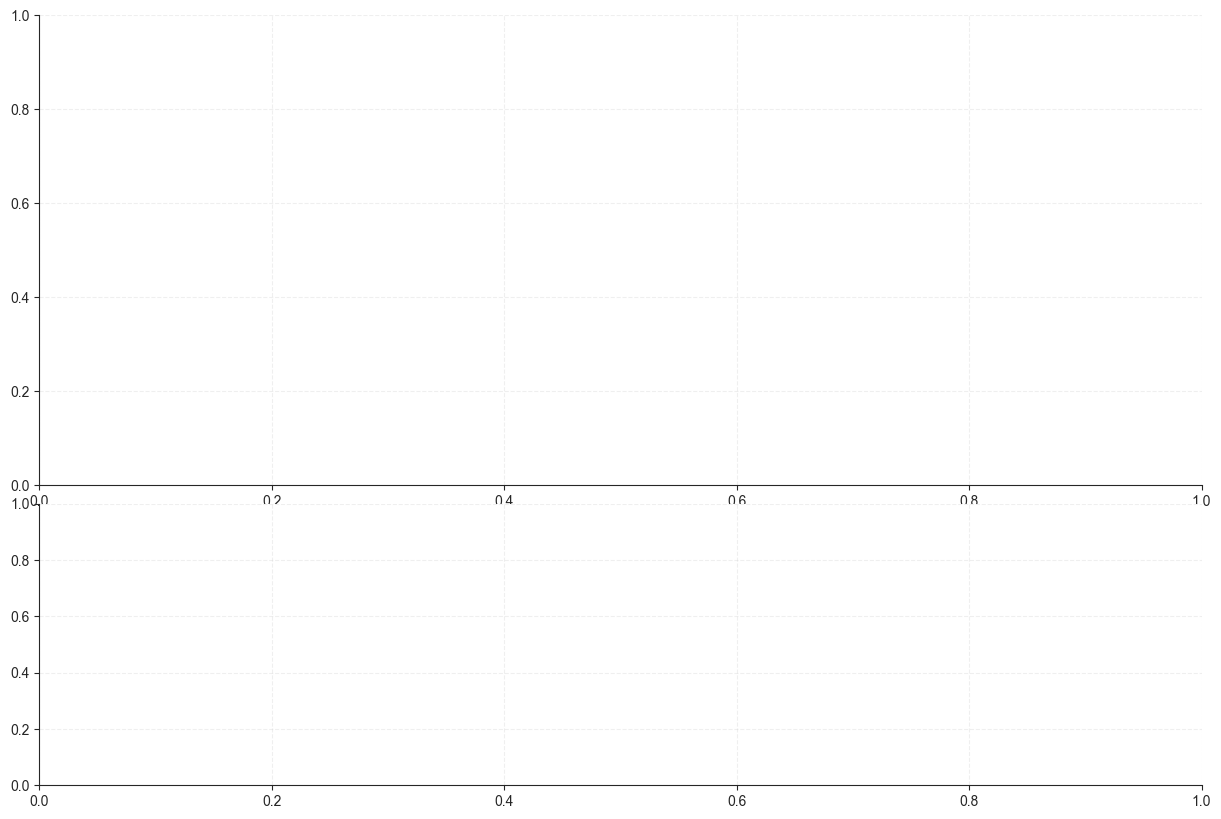

In [64]:
# Visualization 9: Combined Distance and Logo Plot

if distance_table is not None and residue_table_for_logo is not None and not distance_table.empty and not residue_table_for_logo.empty:
    # Create combined plot
    fig_combined = create_combined_distance_logo_plot(distance_table, residue_table_for_logo)
    plt.show()